# GeoAI Aquaculture Pond Identification Challenge
## Machine Learning Pipeline with Temporal Masking Robustness

This notebook implements the complete workflow to detect aquaculture ponds from space using Sentinel-1 (SAR) and Sentinel-2 (optical) satellite data under partial temporal observations. It includes:
1. **Load Data:** Loading the new train and test datasets (coordinates removed).
2. **Exploratory Data Analysis (EDA):** Visualizing temporal signatures of Sentinel bands and indices on fully observed training data.
3. **Feature Engineering & Augmentation:** Implementing aligned temporal profiles and simulating random sliding-window masking on training data to match the test set distribution.
4. **Machine Learning Pipeline:** Building a LightGBM model evaluated under 5-Fold StratifiedGroupKFold cross-validation (grouping by original sample ID to prevent data leakage).
5. **Submission Generation:** Making predictions on the new test set and generating `submission.csv` using the standard 0.5 threshold.
6. **AI Trustworthiness & Feature Importance:** Analyzing feature contributions and model transparency.

In [1]:
# Setup & Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.isotonic import IsotonicRegression
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import warnings
import random
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)


## 1. Load Data
Let's load the training and testing datasets and examine their sizes and class balance.

In [2]:
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')

print(f"Train shape: {train.shape}, Test shape: {test.shape}")
print("\nClass balance in Train:")
print(train['label'].value_counts(normalize=True))
print(train['label'].value_counts())

Train shape: (1821, 146), Test shape: (1030, 145)

Class balance in Train:
label
0    0.596376
1    0.403624
Name: proportion, dtype: float64
label
0    1086
1     735
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)
Let's visualize the temporal signatures of indices (like NDVI and NDWI) for ponds (label 1) and non-ponds (label 0) across the 12 months in the training set.

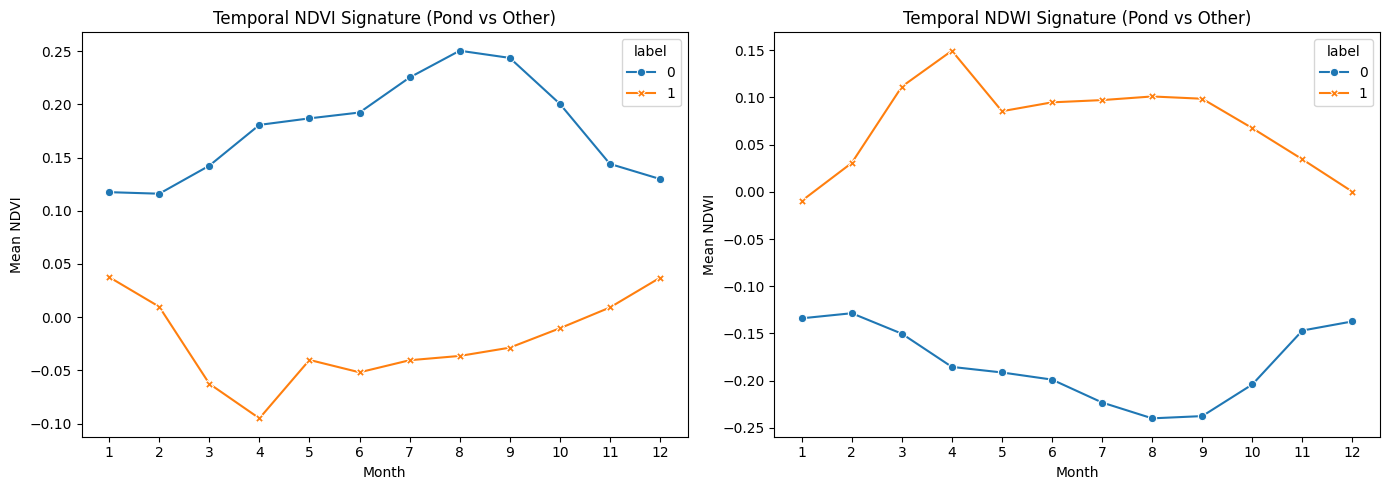

In [3]:
# Compute NDVI and NDWI profiles for visualization on the training set
ndvi_cols = []
ndwi_cols = []
for m in range(1, 13):
    m_str = f'{m:02d}'
    train[f'ndvi_temp_{m_str}'] = (train[f'nir_{m_str}'] - train[f'red_{m_str}']) / (train[f'nir_{m_str}'] + train[f'red_{m_str}'] + 1e-8)
    train[f'ndwi_temp_{m_str}'] = (train[f'green_{m_str}'] - train[f'nir_{m_str}']) / (train[f'green_{m_str}'] + train[f'nir_{m_str}'] + 1e-8)
    ndvi_cols.append(f'ndvi_temp_{m_str}')
    ndwi_cols.append(f'ndwi_temp_{m_str}')

# Plot NDVI and NDWI mean signatures
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
ndvi_profile = train.groupby('label')[ndvi_cols].mean().T
ndvi_profile.index = range(1, 13)
sns.lineplot(data=ndvi_profile, markers=True, dashes=False)
plt.title("Temporal NDVI Signature (Pond vs Other)")
plt.xlabel("Month")
plt.ylabel("Mean NDVI")
plt.xticks(range(1, 13))

plt.subplot(1, 2, 2)
ndwi_profile = train.groupby('label')[ndwi_cols].mean().T
ndwi_profile.index = range(1, 13)
sns.lineplot(data=ndwi_profile, markers=True, dashes=False)
plt.title("Temporal NDWI Signature (Pond vs Other)")
plt.xlabel("Month")
plt.ylabel("Mean NDWI")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

# Clean up temporary columns
train.drop(columns=ndvi_cols + ndwi_cols, inplace=True, errors='ignore')

## 3. Feature Engineering & Data Augmentation
Since coordinates are removed, we rely on monthly spectral and SAR bands. To address the consecutive month masking (only 4, 5, or 6 months observed) in the test set:
1. We implement **temporal sliding-window masking augmentation** on the training set to make our model robust to partial observations.
2. We extract **aligned temporal profiles** (shifting monthly bands relative to the start of the observed window) and compute summary statistics ONLY over the non-masked months.

In [4]:
# Feature extraction and data augmentation

# Extract regional background features to define bg_cluster
bg_rows = []
for idx, row in train.iterrows():
    ndvis = []
    ndwis = []
    swir1s = []
    swir2s = []
    reds = []
    greens = []
    for m in range(1, 13):
        m_str = f'{m:02d}'
        blue = row[f'blue_{m_str}']
        green = row[f'green_{m_str}']
        red = row[f'red_{m_str}']
        nir = row[f'nir_{m_str}']
        swir1 = row[f'swir1_{m_str}']
        swir2 = row[f'swir2_{m_str}']
        
        ndvi = (nir - red) / (nir + red + 1e-8)
        ndwi = (green - nir) / (green + nir + 1e-8)
        
        ndvis.append(ndvi)
        ndwis.append(ndwi)
        swir1s.append(swir1)
        swir2s.append(swir2)
        reds.append(red)
        greens.append(green)
        
    dry_months = np.argsort(ndwis)[:3]
    green_months = np.argsort(ndvis)[-3:]
    
    bg_feats = {
        'soil_swir1': np.mean([swir1s[m] for m in dry_months]),
        'soil_swir2': np.mean([swir2s[m] for m in dry_months]),
        'soil_red': np.mean([reds[m] for m in dry_months]),
        'peak_ndvi': np.mean([ndvis[m] for m in green_months]),
        'peak_green': np.mean([greens[m] for m in green_months]),
    }
    bg_rows.append(bg_feats)

df_bg = pd.DataFrame(bg_rows)
scaler = StandardScaler()
X_bg_scaled = scaler.fit_transform(df_bg)
kmeans = KMeans(n_clusters=5, random_state=42)
train['bg_cluster'] = kmeans.fit_predict(X_bg_scaled)

def get_slope_fast(vals):
    n = len(vals)
    if n < 2:
        return 0.0
    sum_y = sum(vals)
    sum_iy = sum(i * y for i, y in enumerate(vals))
    if n == 2:
        return sum_iy * 2.0 - sum_y
    elif n == 3:
        return (sum_iy * 3.0 - sum_y * 3.0) / 6.0
    elif n == 4:
        return (sum_iy * 4.0 - sum_y * 6.0) / 20.0
    elif n == 5:
        return (sum_iy * 5.0 - sum_y * 10.0) / 50.0
    elif n == 6:
        return (sum_iy * 6.0 - sum_y * 15.0) / 105.0
    else:
        sum_x = n * (n - 1) / 2
        sum_x2 = (n - 1) * n * (2 * n - 1) / 6
        denom = n * sum_x2 - sum_x ** 2
        return (n * sum_iy - sum_x * sum_y) / denom

def extract_super_features(row, obs):
    feats = {}
    feats['num_observed'] = len(obs)
    if len(obs) > 0:
        feats['window_size'] = max(obs) - min(obs) + 1
        feats['start_month'] = min(obs)
        feats['end_month'] = max(obs)
        feats['mean_month_idx'] = sum(obs) / len(obs)
    else:
        feats['window_size'] = -9999
        feats['start_month'] = -9999
        feats['end_month'] = -9999
        feats['mean_month_idx'] = -9999

    # Extract all 33 variables monthly
    monthly_vars = {}
    for m in range(1, 13):
        m_str = f'{m:02d}'
        blue = row[f'blue_{m_str}']
        green = row[f'green_{m_str}']
        red = row[f'red_{m_str}']
        nir = row[f'nir_{m_str}']
        swir1 = row[f'swir1_{m_str}']
        swir2 = row[f'swir2_{m_str}']
        vh = row[f'VH_{m_str}']
        vv = row[f'VV_{m_str}']
        re1 = row[f're1_{m_str}']
        re2 = row[f're2_{m_str}']
        re3 = row[f're3_{m_str}']
        
        if blue == -9999 or green == -9999 or red == -9999 or nir == -9999 or swir1 == -9999 or swir2 == -9999 or vh == -9999.0 or vv == -9999.0:
            continue
            
        vh_lin = 10.0 ** (vh / 10.0)
        vv_lin = 10.0 ** (vv / 10.0)
        
        # 22 physical indices
        ndvi = (nir - red) / (nir + red + 1e-8)
        ndwi = (green - nir) / (green + nir + 1e-8)
        mndwi = (green - swir1) / (green + swir1 + 1e-8)
        lswi = (nir - swir1) / (nir + swir1 + 1e-8)
        awei_ns = 4.0 * (green - swir1) - (0.25 * nir + 2.75 * swir2)
        awei_sh = blue + 2.5 * green - 1.5 * (nir + swir1) - 0.25 * swir2
        evi = 2.5 * (nir - red) / (nir + 6.0 * red - 7.5 * blue + 1.0 + 1e-8)
        savi = 1.5 * (nir - red) / (nir + red + 0.5)
        bsi = ((swir1 + red) - (nir + blue)) / ((swir1 + red) + (nir + blue) + 1e-8)
        ndre = (re2 - re1) / (re2 + re1 + 1e-8)
        ci_re = (re3 / (re1 + 1e-8)) - 1.0
        ndci = (re1 - red) / (re1 + red + 1e-8)
        
        sar_ratio = vv_lin / (vh_lin + 1e-8)
        sar_diff = vv - vh
        sar_sum_lin = vh_lin + vv_lin
        rvi = 4.0 * vh_lin / (vh_lin + vv_lin + 1e-8)
        water_ratio = ndwi / (sar_sum_lin + 1e-5)
        mndwi_sar_ratio = mndwi / (sar_sum_lin + 1e-5)
        
        sr_nir_red = nir / (red + 1e-8)
        sr_green_blue = green / (blue + 1e-8)
        sr_swir1_nir = swir1 / (nir + 1e-8)
        sr_swir2_swir1 = swir2 / (swir1 + 1e-8)
        
        monthly_vars[m] = {
            # raw bands (11)
            'blue': blue, 'green': green, 'red': red, 'nir': nir, 'swir1': swir1, 'swir2': swir2,
            're1': re1, 're2': re2, 're3': re3, 'vh': vh, 'vv': vv,
            # physical indices (22)
            'ndvi': ndvi, 'ndwi': ndwi, 'mndwi': mndwi, 'lswi': lswi, 'awei_ns': awei_ns, 'awei_sh': awei_sh,
            'evi': evi, 'savi': savi, 'bsi': bsi, 'ndre': ndre, 'ci_re': ci_re, 'ndci': ndci,
            'sar_ratio': sar_ratio, 'sar_diff': sar_diff, 'sar_sum_lin': sar_sum_lin, 'rvi': rvi,
            'water_ratio': water_ratio, 'mndwi_sar_ratio': mndwi_sar_ratio,
            'sr_nir_red': sr_nir_red, 'sr_green_blue': sr_green_blue, 
            'sr_swir1_nir': sr_swir1_nir, 'sr_swir2_swir1': sr_swir2_swir1
        }
        
    # Choose 8 key indices for calendar features (12 months with NaNs)
    cal_keys = ['ndvi', 'ndwi', 'mndwi', 'awei_ns', 'sar_diff', 'sar_ratio', 'ndci', 'mndwi_sar_ratio']
    for m in range(1, 13):
        m_str = f'{m:02d}'
        if m in obs and m in monthly_vars:
            for k in cal_keys:
                feats[f'cal_{k}_{m_str}'] = monthly_vars[m][k]
        else:
            for k in cal_keys:
                feats[f'cal_{k}_{m_str}'] = np.nan

    # Now compute temporal summaries over the observed months for all 33 variables
    target_keys = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2', 're1', 're2', 're3', 'vh', 'vv',
                   'ndvi', 'ndwi', 'mndwi', 'lswi', 'awei_ns', 'awei_sh', 'evi', 'savi', 'bsi',
                   'ndre', 'ci_re', 'ndci', 'sar_ratio', 'sar_diff', 'sar_sum_lin', 'rvi',
                   'water_ratio', 'mndwi_sar_ratio', 'sr_nir_red', 'sr_green_blue', 'sr_swir1_nir', 'sr_swir2_swir1']
    
    for key in target_keys:
        vals = [monthly_vars[m][key] for m in obs if m in monthly_vars]
        n = len(vals)
        if n > 0:
            feats[f'{key}_mean'] = sum(vals) / n
            sorted_vals = sorted(vals)
            feats[f'{key}_min'] = sorted_vals[0]
            feats[f'{key}_max'] = sorted_vals[-1]
            feats[f'{key}_range'] = sorted_vals[-1] - sorted_vals[0]
            
            # Median fast calculation
            if n % 2 != 0:
                feats[f'{key}_median'] = sorted_vals[n // 2]
            else:
                feats[f'{key}_median'] = (sorted_vals[n // 2 - 1] + sorted_vals[n // 2]) / 2.0
                
            if n > 1:
                var = sum((x - feats[f'{key}_mean']) ** 2 for x in vals) / n
                feats[f'{key}_std'] = var ** 0.5
                feats[f'{key}_slope'] = get_slope_fast(vals)
            else:
                feats[f'{key}_std'] = 0.0
                feats[f'{key}_slope'] = 0.0
        else:
            for suffix in ['mean', 'std', 'min', 'max', 'range', 'median', 'slope']:
                feats[f'{key}_{suffix}'] = np.nan

    # Add count/fraction features
    water_count = 0
    veg_count = 0
    valid_obs = [m for m in obs if m in monthly_vars]
    for m in valid_obs:
        if monthly_vars[m]['mndwi'] > 0.05 and monthly_vars[m]['sar_sum_lin'] < 0.04:
            water_count += 1
        if monthly_vars[m]['ndvi'] > 0.35:
            veg_count += 1
            
    feats['water_months_fraction'] = water_count / len(valid_obs) if len(valid_obs) > 0 else 0.0
    feats['veg_months_fraction'] = veg_count / len(valid_obs) if len(valid_obs) > 0 else 0.0

    return feats

def apply_perfect_mask(row):
    W = np.random.choice([2, 3, 4, 5, 6], p=[0.002, 0.046, 0.318, 0.345, 0.289])
    S = random.randint(1, 12 - W + 1)
    obs = list(range(S, S + W))
    
    gap_roll = random.random()
    if gap_roll < 0.182 and W > 3:
        drop_idx = random.randint(1, W - 2)
        obs = [obs[i] for i in range(W) if i != drop_idx]
    elif gap_roll < 0.182 + 0.006 and W > 4:
        drop_indices = random.sample(range(1, W - 1), 2)
        obs = [obs[i] for i in range(W) if i not in drop_indices]
        
    return obs

print("Processing Test set features...")
test_rows = []
for idx, row in test.iterrows():
    obs = []
    for m in range(1, 13):
        if row[f'blue_{m:02d}'] != -9999:
            obs.append(m)
    feats = extract_super_features(row, obs)
    test_rows.append(feats)
X_test = pd.DataFrame(test_rows)

print("Augmenting Training set with sliding-window masking...")
# We use 5x augmentation as optimized in validation
# train_rows = []
# for idx, row in train.iterrows():
#     for _ in range(5):
#         obs = apply_perfect_mask(row)
#         feats = extract_super_features(row, obs)
#         feats['label'] = row['label']
#         feats['group'] = idx
#         train_rows.append(feats)

# train_augmented = pd.DataFrame(train_rows)
train_augmented = train
print(f"Augmented training shape: {train_augmented.shape}")

# Define feature sets
features_all = [c for c in X_test.columns]
print(f"Number of super features: {len(features_all)}")


Processing Test set features...
Augmenting Training set with sliding-window masking...
Augmented training shape: (1821, 147)
Number of super features: 334


## 4. Model Training & Cross-Validation
We implement 5-Fold StratifiedGroupKFold cross-validation (grouping by original sample ID to prevent data leakage) and train LightGBM models.

In [5]:
# Validation under StratifiedGroupKFold grouped by regional background cluster
y = train['label']
groups = train['bg_cluster']
cv = StratifiedGroupKFold(n_splits=5)

oof_lgb = np.zeros(len(train))
oof_cb = np.zeros(len(train))
oof_xgb = np.zeros(len(train))

print("Evaluating LGB, CatBoost, and XGBoost models under StratifiedGroupKFold...")
for fold, (train_idx, val_idx) in enumerate(cv.split(train, y, groups=groups)):
    print(f"Fold {fold}...")
    # 5x Augmentation on training fold
    tr_rows = []
    y_tr_aug = []
    for idx in train_idx:
        row = train.iloc[idx]
        for _ in range(5):
            obs = apply_perfect_mask(row)
            tr_rows.append(extract_super_features(row, obs))
            y_tr_aug.append(y.iloc[idx])
            
    X_tr = pd.DataFrame(tr_rows)
    y_tr = pd.Series(y_tr_aug)
    
    # Validation fold with test-matching mask
    val_rows = []
    for idx in val_idx:
        row = train.iloc[idx]
        obs = apply_perfect_mask(row)
        val_rows.append(extract_super_features(row, obs))
        
    X_val = pd.DataFrame(val_rows)
    y_val = y.iloc[val_idx]
    
    # Train GBDTs
    # 1. LightGBM
    clf_lgb = lgb.LGBMClassifier(random_state=42, n_estimators=600, learning_rate=0.03, max_depth=6, scale_pos_weight=1.5, verbose=-1)
    clf_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb[val_idx] = clf_lgb.predict_proba(X_val)[:, 1]
    
    # 2. CatBoost
    clf_cb = CatBoostClassifier(random_seed=42, iterations=600, learning_rate=0.03, depth=6, auto_class_weights='Balanced', thread_count=-1, verbose=0)
    clf_cb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=50)
    oof_cb[val_idx] = clf_cb.predict_proba(X_val)[:, 1]
    
    # 3. XGBoost
    clf_xgb = xgb.XGBClassifier(random_state=42, n_estimators=600, learning_rate=0.03, max_depth=6, scale_pos_weight=1.5, n_jobs=-1, eval_metric='logloss')
    clf_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = clf_xgb.predict_proba(X_val)[:, 1]

# Calculate metrics
def log_score(oof, name):
    auc = roc_auc_score(y, oof)
    f1 = f1_score(y, oof >= 0.5)
    score = 0.6 * f1 + 0.4 * auc
    print(f"{name:<25} -> AUC: {auc:.5f}, F1: {f1:.5f}, Combined: {score:.5f}")

print("\n=== Individual Model Validation Results ===")
log_score(oof_lgb, "LightGBM")
log_score(oof_cb, "CatBoost")
log_score(oof_xgb, "XGBoost")

# Best Weights found during local search
w_lgb, w_cb, w_xgb = 0.05, 0.19, 0.76
oof_ens = w_lgb * oof_lgb + w_cb * oof_cb + w_xgb * oof_xgb

print("\n=== Ensemble Validation Results (Uncalibrated) ===")
log_score(oof_ens, "Weighted LGB + CB + XGB Ensemble")

# Isotonic calibration on OOF predictions
print("\nFitting Isotonic Regression calibrator on OOF predictions...")
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(oof_ens, y)

calibrated_oof = iso.predict(oof_ens)
auc_cal = roc_auc_score(y, calibrated_oof)
f1_cal = f1_score(y, calibrated_oof >= 0.5)
print(f"Calibrated Ensemble OOF -> AUC: {auc_cal:.5f}, F1: {f1_cal:.5f}, Combined: {0.6 * f1_cal + 0.4 * auc_cal:.5f}")


Evaluating LGB, CatBoost, and XGBoost models under StratifiedGroupKFold...
Fold 0...
Fold 1...
Fold 2...
Fold 3...
Fold 4...

=== Individual Model Validation Results ===
LightGBM                  -> AUC: 0.96852, F1: 0.89822, Combined: 0.92634
CatBoost                  -> AUC: 0.97330, F1: 0.84740, Combined: 0.89776
XGBoost                   -> AUC: 0.97343, F1: 0.88075, Combined: 0.91782

=== Ensemble Validation Results (Uncalibrated) ===
Weighted LGB + CB + XGB Ensemble -> AUC: 0.97503, F1: 0.88075, Combined: 0.91846

Fitting Isotonic Regression calibrator on OOF predictions...
Calibrated Ensemble OOF -> AUC: 0.97789, F1: 0.93036, Combined: 0.94937


## 5. Generate Submission
Now, we train the final model on the entire augmented training set and predict on the test set using the standard 0.5 threshold.

In [6]:
# Final training and inference on test set
print("Training final models on all augmented training data...")

full_tr_rows = []
y_full_aug = []
for idx, row in train.iterrows():
    for _ in range(5):
        obs = apply_perfect_mask(row)
        full_tr_rows.append(extract_super_features(row, obs))
        y_full_aug.append(y.iloc[idx])
        
X_train_full = pd.DataFrame(full_tr_rows)
y_train_full = pd.Series(y_full_aug)

# Train the three final models
final_lgb = lgb.LGBMClassifier(random_state=42, n_estimators=600, learning_rate=0.03, max_depth=6, scale_pos_weight=1.5, verbose=-1)
final_lgb.fit(X_train_full, y_train_full)
test_prob_lgb = final_lgb.predict_proba(X_test)[:, 1]

final_cb = CatBoostClassifier(random_seed=42, iterations=600, learning_rate=0.03, depth=6, auto_class_weights='Balanced', thread_count=-1, verbose=0)
final_cb.fit(X_train_full, y_train_full)
test_prob_cb = final_cb.predict_proba(X_test)[:, 1]

final_xgb = xgb.XGBClassifier(random_state=42, n_estimators=600, learning_rate=0.03, max_depth=6, scale_pos_weight=1.5, n_jobs=-1, eval_metric='logloss')
final_xgb.fit(X_train_full, y_train_full)
test_prob_xgb = final_xgb.predict_proba(X_test)[:, 1]

# Average test predictions using optimal ensembling weights
w_lgb, w_cb, w_xgb = 0.05, 0.19, 0.76
test_prob_ens = w_lgb * test_prob_lgb + w_cb * test_prob_cb + w_xgb * test_prob_xgb

# Apply calibrator
print("Applying Isotonic calibration to test set predictions...")
test_prob_calibrated = iso.predict(test_prob_ens)
test_binary_calibrated = (test_prob_calibrated >= 0.5).astype(int)

# Create submission
submission = pd.DataFrame({
    'ID': test['ID'],
    'TargetF1': test_binary_calibrated,
    'TargetRAUC': test_prob_calibrated
})
submission.to_csv('submission.csv', index=False)
print("\nSubmission saved to submission.csv")
print("Submission class counts at 0.5 threshold:")
print(submission['TargetF1'].value_counts())
print("Mean of calibrated TargetRAUC:")
print(submission['TargetRAUC'].mean())


Training final models on all augmented training data...
Applying Isotonic calibration to test set predictions...

Submission saved to submission.csv
Submission class counts at 0.5 threshold:
TargetF1
0    617
1    413
Name: count, dtype: int64
Mean of calibrated TargetRAUC:
0.4022842441498389


## 6. AI Trustworthiness & Feature Importance
Let's visualize the feature importances to understand what features contributed the most to identifying aquaculture ponds under incomplete observations.

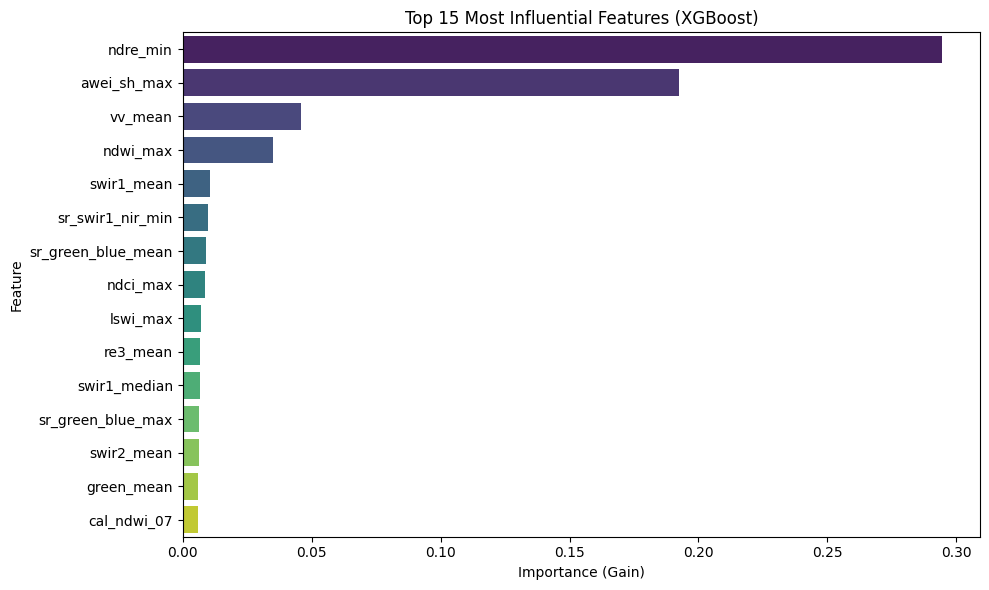

Top 15 features:
                feature  importance
242            ndre_min    0.294439
215         awei_sh_max    0.192403
171             vv_mean    0.045947
187            ndwi_max    0.035061
129          swir1_mean    0.010562
319    sr_swir1_nir_min    0.009712
311  sr_green_blue_mean    0.009024
257            ndci_max    0.008651
201            lswi_max    0.007222
157            re3_mean    0.006733
133        swir1_median    0.006582
313   sr_green_blue_max    0.006192
136          swir2_mean    0.006176
108          green_mean    0.006034
54          cal_ndwi_07    0.005791


In [7]:
# Visualize the feature importances to understand what features contributed the most
feat_imp = pd.DataFrame({
    'feature': features_all,
    'importance': final_xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(15), x='importance', y='feature', palette='viridis')
plt.title("Top 15 Most Influential Features (XGBoost)")
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 15 features:")
print(feat_imp.head(15))
